In [1]:
import cv2
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
from skimage.feature import hog

In [2]:
import glob
car=glob.glob('data/car/**/*.png')
no_car=glob.glob('data/no car/**/*.png')



In [3]:
len(car)

8792

In [4]:
len(no_car)

8968

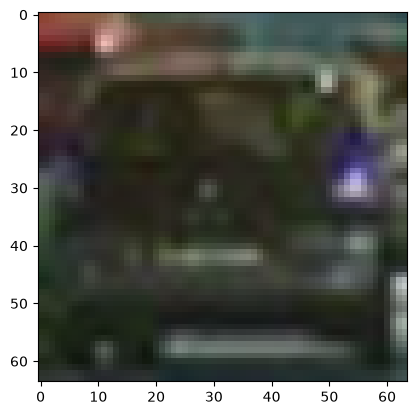

In [5]:
image_c=cv2.imread(car[300])
plt.imshow(image_c)

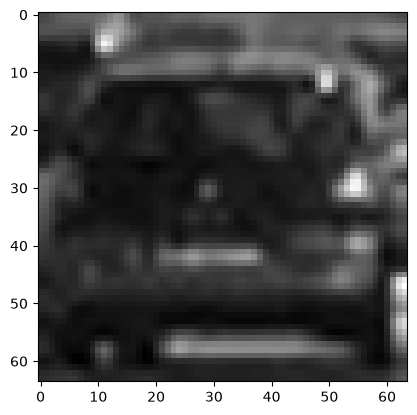

In [6]:
image_g=cv2.cvtColor(image_c,cv2.COLOR_BGR2GRAY)
plt.imshow(image_g,cmap='gray')

get Hog features

In [7]:
features, hog_image=hog(image_g,
                        orientations=11,
                        pixels_per_cell=(16,16),
                        cells_per_block=(2,2),
                        transform_sqrt=False,
                        visualize=True,
                        feature_vector=True)

features.shape

(396,)

In [8]:
hog_image.shape

(64, 64)

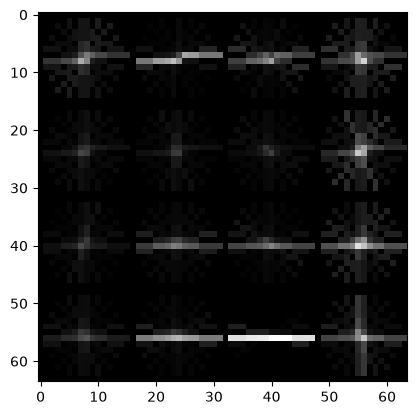

In [9]:
plt.imshow(hog_image,cmap='gray')

Hog Features Extraction and training dataset creation

In [10]:
car_hog_accum=[]
for i in car:
    image_color=mpimg.imread(i)
    image_gray=cv2.cvtColor(image_color,cv2.COLOR_BGR2GRAY)
    
    
    car_hog_features, car_hog_image=hog(image_color[:,:,0],
                        orientations=11,
                        pixels_per_cell=(16,16),
                        cells_per_block=(2,2),
                        transform_sqrt=False,
                        visualize=True,
                        feature_vector=True)
    
    car_hog_accum.append(car_hog_features)

In [11]:
X_car=np.vstack((car_hog_accum)).astype(np.float64)
y_car=np.ones(len(X_car))

In [12]:
X_car.shape

(8792, 396)

In [13]:
y_car.shape

(8792,)

In [14]:
y_car[:]

array([1., 1., 1., ..., 1., 1., 1.], shape=(8792,))

In [15]:
no_car_hog_accum=[]
for i in no_car:
    image_color=mpimg.imread(i)
    image_gray=cv2.cvtColor(image_color,cv2.COLOR_BGR2GRAY)
    
    
    no_car_hog_features, no_car_hog_image=hog(image_color[:,:,0],
                        orientations=11,
                        pixels_per_cell=(16,16),
                        cells_per_block=(2,2),
                        transform_sqrt=False,
                        visualize=True,
                        feature_vector=True)
    
    no_car_hog_accum.append(no_car_hog_features)

In [16]:
X_no_car=np.vstack(no_car_hog_accum).astype(np.float64)
y_no_car=np.zeros(len(X_no_car))


In [17]:
X_no_car.shape

(8968, 396)

In [18]:
X_no_car[2]

array([0.20868278, 0.21329162, 0.10382297, 0.17050572, 0.13608111,
       0.2067731 , 0.06510075, 0.08572048, 0.0627018 , 0.11805875,
       0.09318274, 0.21329162, 0.21329162, 0.17900202, 0.15639775,
       0.14516835, 0.15207106, 0.13388202, 0.21329162, 0.21329162,
       0.16775808, 0.21329162, 0.14224643, 0.11382293, 0.21329162,
       0.18307079, 0.14566849, 0.14029343, 0.07328432, 0.10045595,
       0.06800196, 0.11900105, 0.20574567, 0.07678664, 0.10443097,
       0.09020396, 0.103581  , 0.09655492, 0.18216068, 0.12711167,
       0.14417888, 0.12801859, 0.13019986, 0.13900644, 0.2186444 ,
       0.2186444 , 0.1984534 , 0.17339282, 0.16094317, 0.16859597,
       0.14843041, 0.2186444 , 0.2186444 , 0.18598764, 0.2186444 ,
       0.19818924, 0.12701762, 0.09341722, 0.11803182, 0.10663166,
       0.09957836, 0.08490481, 0.15237983, 0.09711679, 0.11667895,
       0.14409432, 0.08513071, 0.11577903, 0.10000604, 0.11483669,
       0.10704713, 0.20195529, 0.14092435, 0.15984619, 0.14192

In [19]:
X=np.vstack((X_car,X_no_car))
X.shape

(17760, 396)

In [20]:
y=np.hstack((y_car,y_no_car))
y.shape

(17760,)

SVM MODEL Classifier Tranininng

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,stratify=y,random_state=101)

In [22]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report,confusion_matrix

svc_model=LinearSVC()
svc_model.fit(X_train,y_train)



,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

<Axes: >

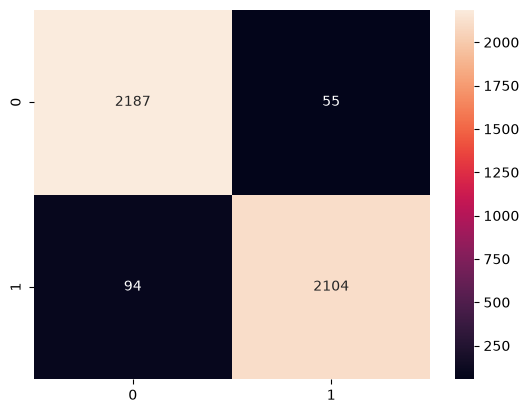

In [23]:
y_predict=svc_model.predict(X_test)
cm=confusion_matrix(y_test,y_predict)
sns.heatmap(cm,annot=True,fmt='d')

Improve the model

In [24]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      2242
         1.0       0.97      0.96      0.97      2198

    accuracy                           0.97      4440
   macro avg       0.97      0.97      0.97      4440
weighted avg       0.97      0.97      0.97      4440



In [25]:
from sklearn.svm import SVC

In [26]:
Model={
    
}

In [27]:
param_grid={
    'C':[0.1,10,100],
    'gamma':[1,0.1,0.01,0.001],
    'kernel':['rbf','linear']
    }

In [28]:
from sklearn.model_selection import GridSearchCV

gscv=GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    n_jobs=-1,
    refit=True,
    verbose=4,
    scoring='recall_weighted'    
    
)


In [29]:
gscv.fit(X_train,y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 10, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother case

In [30]:
gscv.best_params_
gscv.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [31]:
from sklearn.pipeline import Pipeline

In [32]:
best_pipeline=Pipeline(
    steps=[
        ('model',SVC(kernel="rbf",gamma=1,C=10,degree=3))
    ]
)

In [33]:
best_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,396
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3


<Axes: >

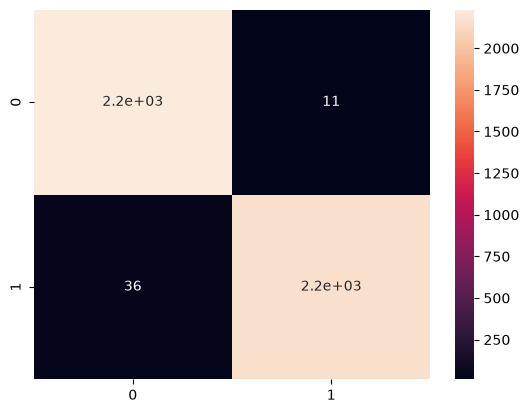

In [34]:
y_pred_best_pipeline=best_pipeline.predict(X_test)

cm=confusion_matrix(y_test,y_pred_best_pipeline)

sns.heatmap(cm,annot=True)


In [35]:
print(classification_report(y_test,y_pred_best_pipeline))

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2242
         1.0       0.99      0.98      0.99      2198

    accuracy                           0.99      4440
   macro avg       0.99      0.99      0.99      4440
weighted avg       0.99      0.99      0.99      4440



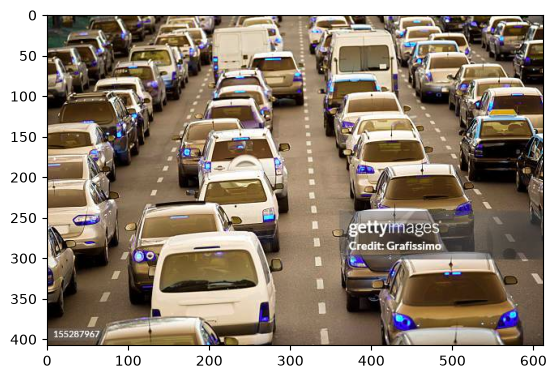

In [36]:
test_image=cv2.imread('test_image.jpg')
plt.imshow(test_image)
test_image=test_image.astype(np.float32)/255

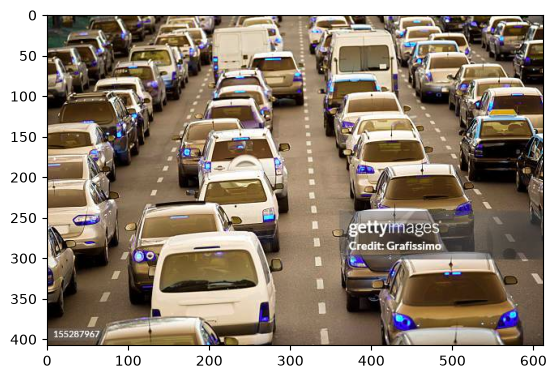

In [37]:
plt.imshow(test_image)

(108, 612, 3)

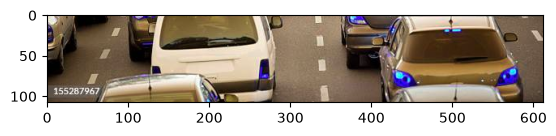

In [38]:
h_start=300
h_stop=730

pixels_in_cell=16
HOG_orientation=11
cell_in_block=2
cells_in_stop=3

masked_region=test_image[h_start:h_stop,:,:]
plt.imshow(masked_region)
masked_region.shape


resize the image


In [39]:
resize_factor=2
masked_region_shape=masked_region.shape
L=masked_region_shape[1]/resize_factor
W=masked_region_shape[0]/resize_factor


(54, 306, 3)


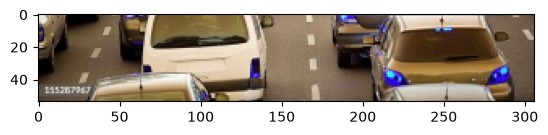

In [40]:
masked_region_resized=cv2.resize(masked_region,(np.int64(L),np.int64(W)))
masked_region_resized_R=masked_region_resized[:,:,0]

print(masked_region_resized.shape)
plt.imshow(masked_region_resized)

In [41]:
print(masked_region_resized_R.shape)
masked_region_hog_feature_all=hog(masked_region_resized_R,
                                          orientations=11,
                                          pixels_per_cell=(16,16),
                                          cells_per_block=(2,2),
                                          transform_sqrt=False,
                                          visualize=False,
                                          feature_vector=False)

(54, 306)


In [42]:
n_blocks_x=(masked_region_resized_R.shape[1]//pixels_in_cell)+1
n_blocks_y=(masked_region_resized_R.shape[0]//pixels_in_cell)+1

#nfeat_per_block=orientation*cells_in_block**2

blocks_in_window=(64//pixels_in_cell)-1

stops_x=(n_blocks_x-blocks_in_window)//cells_in_stop
stops_y=(n_blocks_y-blocks_in_window)//cells_in_stop

rectangle_found=[]
for xb in range(stops_x):
    for yb in range(stops_y):
        y_position=yb*cells_in_stop
        x_position=xb*cells_in_stop
        print(masked_region_hog_feature_all.shape)
        print(masked_region_hog_feature_all.ndim)
        hog_feat_sample=masked_region_hog_feature_all[y_position:  y_position + blocks_in_window,x_position: x_position +blocks_in_window]
        x_left= x_position*pixels_in_cell
        y_top=y_position*pixels_in_cell
        print(hog_feat_sample.shape)
        test_prediction=best_pipeline.predict(hog_feat_sample.reshape(1,-1))
        
        
        if test_prediction[0]==1:
            rectangle_x_left=np.int64(x_left*resize_factor)
            rectangle_y_top=np.int64(y_top*resize_factor)
            window_dim=np.int64(64*resize_factor)
            rectangle_found.append(((rectangle_x_left,rectangle_y_top+h_start),(rectangle_x_left+window_dim,rectangle_y_top)))
            
            
            
        
        
        
        


In [43]:
rectangle_found

[]

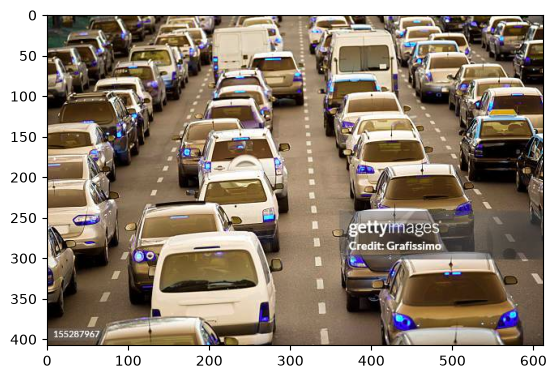

In [44]:
image_with_rectangle=np.copy(test_image)
for rectangle in rectangle_found:
    cv2.rectangle(image_with_rectangle,rectangle[0],rectangle[1],(0,0,255),20)
plt.imshow(image_with_rectangle)